In [4]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import normflows as nf
import formula as fo
import time

torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

epoch     1 | loss = 7634.0625 | tau = 1.0000 | anneal_beta = 1.0000
epoch   500 | loss = 190.8898 | tau = 0.8257 | anneal_beta = 1.0000
epoch  1000 | loss = 184.2325 | tau = 0.6815 | anneal_beta = 1.0000
epoch  1500 | loss = 178.6788 | tau = 0.5625 | anneal_beta = 1.0000
epoch  2000 | loss = 175.5474 | tau = 0.4643 | anneal_beta = 1.0000
epoch  2500 | loss = 173.0339 | tau = 0.3832 | anneal_beta = 1.0000
epoch  3000 | loss = 171.6988 | tau = 0.3163 | anneal_beta = 1.0000
epoch  3500 | loss = 170.6693 | tau = 0.2611 | anneal_beta = 1.0000
epoch  4000 | loss = 170.9196 | tau = 0.2155 | anneal_beta = 1.0000
epoch  4500 | loss = 170.6068 | tau = 0.1778 | anneal_beta = 1.0000
epoch  5000 | loss = 173.1395 | tau = 0.1468 | anneal_beta = 1.0000
epoch  5500 | loss = 174.4607 | tau = 0.1212 | anneal_beta = 1.0000
epoch  6000 | loss = 170.7769 | tau = 0.1000 | anneal_beta = 1.0000


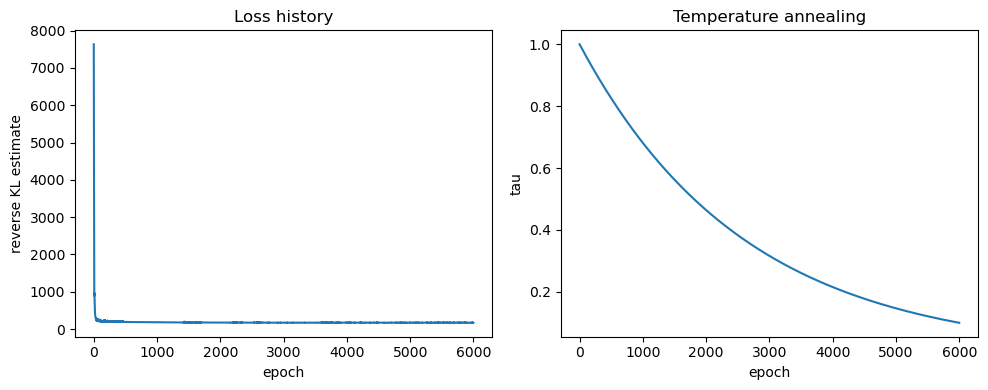


===== flow_type = affine_coupling =====

===== Variable selection summary =====
selected indices: [0, 1, 2, 3, 4]
TP: 5 FP: 0 FN: 0
precision: 1.0
recall   : 1.0

first 20 posterior inclusion probabilities:
tensor([9.9988e-01, 9.8513e-01, 8.9325e-01, 9.9988e-01, 9.8212e-01, 2.5000e-04,
        1.2500e-04, 0.0000e+00, 1.2500e-04, 0.0000e+00, 0.0000e+00, 1.2500e-04,
        1.2500e-04, 2.5000e-04, 1.2500e-04, 0.0000e+00, 0.0000e+00, 1.2500e-04,
        1.2500e-04, 0.0000e+00])

first 20 beta soft posterior means:
tensor([ 1.5019e+00, -6.6525e-01,  6.9832e-01, -1.1752e+00,  5.7555e-01,
         1.0897e-05, -3.9353e-05,  8.2570e-05, -9.9334e-05, -7.1077e-05,
         1.9104e-05, -1.2286e-05,  2.8735e-05,  7.4494e-05, -8.9114e-05,
         8.5228e-05, -1.5928e-05, -4.1133e-05, -8.5381e-07,  1.7423e-05])

first 20 beta hard posterior means:
tensor([ 1.5864e+00, -7.3123e-01,  7.4931e-01, -1.2264e+00,  6.6043e-01,
         4.9472e-05,  1.8864e-05,  0.0000e+00, -1.0279e-04,  0.0000e+00,
      

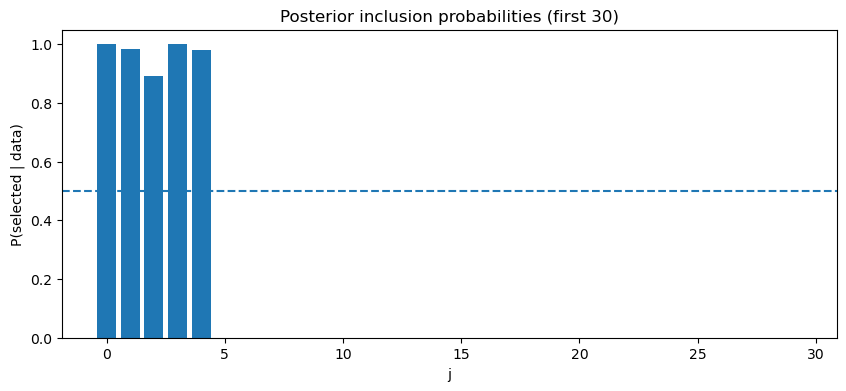

In [3]:
n = 200
p = 100
sigma2 = 0.5

X, y, beta_true = fo.make_regression_data(n=n, p=p, sigma2=sigma2, device=device,)

Sigma = torch.eye(p, device=device)

target_dist = fo.RelaxedSpikeSlabTarget(X=X, y=y, sigma2=sigma2, lambda_s=1.0, mu_t=0.0,
    sigma_t=1.0, tau=1.0, slab="laplace",).to(device)

flow_type = "affine_coupling"

model = fo.build_nf(
    latent_dim=target_dist.latent_dim,
    target_dist=target_dist,
    flow_type=flow_type,
    K=8,
    hidden_units=128,
    num_hidden_layers=2,
    device=device,
)

losses, tau_hist = fo.train_flow(model=model, target_dist=target_dist,
    epochs=6000, num_samples=1024, lr=1e-3, tau_start=1.0, tau_end=0.1,
    kl_anneal=False, grad_clip=5.0, print_every=500,)

fo.plot_training(losses, tau_hist)

post_summary = fo.posterior_summary(
    model=model,
    target_dist=target_dist,
    n_samples=8000,
    gate_threshold=0.5,  
    inclusion_threshold=0.5, 
)

print(f"\n===== flow_type = {flow_type} =====")
fo.evaluate_against_truth(beta_true, post_summary)

fo.plot_posterior_inclusion_prob(
    post_summary["pip"],
    top_k=30,
    decision_threshold=0.5,
)

In [6]:
def _to_cpu(x):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        return x.detach().cpu()
    return x


def _safe_div(a, b, default=0.0):
    return a / b if b != 0 else default


def summarize_beta_samples(beta_samples: torch.Tensor):
    """
    beta_samples: shape [m, p]
    Returns posterior sample mean and covariance.
    """
    beta_samples = beta_samples.detach()
    mean = beta_samples.mean(dim=0)
    centered = beta_samples - mean
    cov = centered.T @ centered / max(beta_samples.shape[0] - 1, 1)
    return mean, cov


def posterior_predictive_summary(X: torch.Tensor, beta_samples: torch.Tensor):
    """
    X: [n, p]
    beta_samples: [m, p]

    Returns:
        yhat_samples: [m, n]
        yhat_mean:    [n]
        yhat_q025:    [n]
        yhat_q5:      [n]
        yhat_q975:    [n]
    """
    X = X.detach()
    beta_samples = beta_samples.detach()
    yhat_samples = beta_samples @ X.T   # [m, n]

    out = {
        "yhat_samples": yhat_samples,
        "yhat_mean": yhat_samples.mean(dim=0),
        "yhat_q025": yhat_samples.quantile(0.025, dim=0),
        "yhat_q5": yhat_samples.quantile(0.50, dim=0),
        "yhat_q975": yhat_samples.quantile(0.975, dim=0),
    }
    return out


def regression_metrics(y_true: torch.Tensor, y_pred: torch.Tensor):
    """
    Basic regression metrics for point predictions.
    """
    y_true = y_true.detach().cpu()
    y_pred = y_pred.detach().cpu()

    err = y_true - y_pred
    mse = torch.mean(err ** 2).item()
    rmse = math.sqrt(mse)
    mae = torch.mean(torch.abs(err)).item()

    sst = torch.sum((y_true - y_true.mean()) ** 2).item()
    sse = torch.sum(err ** 2).item()
    r2 = 1.0 - sse / sst if sst > 0 else float("nan")

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }


def binary_classification_ranking_metrics(labels, scores):
    """
    Compute AUROC / AUPRC if sklearn is available.
    labels: 0/1 array-like
    scores: continuous scores (e.g. PIP)
    """
    labels = np.asarray(labels).astype(int)
    scores = np.asarray(scores).astype(float)

    if len(np.unique(labels)) < 2:
        return {"auroc": np.nan, "auprc": np.nan}

    try:
        from sklearn.metrics import roc_auc_score, average_precision_score
        return {
            "auroc": float(roc_auc_score(labels, scores)),
            "auprc": float(average_precision_score(labels, scores)),
        }
    except Exception:
        return {"auroc": np.nan, "auprc": np.nan}


# =========================================================
# Posterior summary
# =========================================================

@torch.no_grad()
def posterior_summary(
    model,
    target_dist,
    n_samples=5000,
    gate_threshold=0.5,
    inclusion_threshold=0.5,
):
    """
    Draw posterior samples from the trained flow and summarize:

    - latent samples z = (s, u, t)
    - soft gate / hard gate
    - soft beta / hard beta
    - posterior means / variances / quantiles
    - PIP and selected set
    """

    # -----------------------------------------------------
    # Sample latent variables z from learned posterior q(z)
    # -----------------------------------------------------
    z, _ = model.sample(num_samples=n_samples)

    # Soft quantities
    beta_soft = target_dist.beta_from_latent(z)          # [m, p]
    gate_soft = target_dist.gate_from_latent(z)          # [m, p]

    # Hard thresholding
    gate_hard = (gate_soft > gate_threshold).float()     # [m, p]
    beta_hard = target_dist.hard_beta_from_latent(
        z,
        threshold=gate_threshold
    )                                                    # [m, p]

    # Split latent blocks
    s, u, t = target_dist.split_latent(z)                # s:[m,p], u:[m,p], t:[m,1] or [m]

    # Means
    beta_soft_mean = beta_soft.mean(dim=0)
    beta_hard_mean = beta_hard.mean(dim=0)
    gate_soft_mean = gate_soft.mean(dim=0)

    # Variances
    beta_soft_var = beta_soft.var(dim=0, unbiased=True)
    beta_hard_var = beta_hard.var(dim=0, unbiased=True)
    gate_soft_var = gate_soft.var(dim=0, unbiased=True)

    # Quantiles
    beta_soft_q025 = beta_soft.quantile(0.025, dim=0)
    beta_soft_q50  = beta_soft.quantile(0.50, dim=0)
    beta_soft_q975 = beta_soft.quantile(0.975, dim=0)

    beta_hard_q025 = beta_hard.quantile(0.025, dim=0)
    beta_hard_q50  = beta_hard.quantile(0.50, dim=0)
    beta_hard_q975 = beta_hard.quantile(0.975, dim=0)

    # PIP
    pip = gate_hard.mean(dim=0)

    # Final selected set
    selected = (pip > inclusion_threshold)
    selected_idx = torch.nonzero(selected, as_tuple=False).squeeze(1)

    # Posterior covariance summaries
    beta_soft_cov = summarize_beta_samples(beta_soft)[1]
    beta_hard_cov = summarize_beta_samples(beta_hard)[1]

    out = {
        # raw posterior samples
        "z": z,
        "s": s,
        "u": u,
        "t": t.squeeze(-1) if t.ndim > 1 else t,

        # soft/hard posterior samples
        "beta_soft": beta_soft,
        "beta_hard": beta_hard,
        "gate_soft": gate_soft,
        "gate_hard": gate_hard,

        # posterior means
        "beta_soft_mean": beta_soft_mean,
        "beta_hard_mean": beta_hard_mean,
        "gate_soft_mean": gate_soft_mean,

        # posterior variances
        "beta_soft_var": beta_soft_var,
        "beta_hard_var": beta_hard_var,
        "gate_soft_var": gate_soft_var,

        # posterior covariances
        "beta_soft_cov": beta_soft_cov,
        "beta_hard_cov": beta_hard_cov,

        # posterior quantiles
        "beta_soft_q025": beta_soft_q025,
        "beta_soft_q50": beta_soft_q50,
        "beta_soft_q975": beta_soft_q975,
        "beta_hard_q025": beta_hard_q025,
        "beta_hard_q50": beta_hard_q50,
        "beta_hard_q975": beta_hard_q975,

        # variable-selection summaries
        "pip": pip,
        "selected": selected,
        "selected_idx": selected_idx,

        # thresholds used
        "gate_threshold": gate_threshold,
        "inclusion_threshold": inclusion_threshold,
    }
    return out


# =========================================================
# Truth-based evaluation (for simulation studies)
# =========================================================

def support_recovery_metrics(beta_true: torch.Tensor, pip: torch.Tensor, selected: torch.Tensor):
    """
    Evaluate variable-selection quality using true support.
    """
    beta_true = beta_true.detach().cpu()
    pip = pip.detach().cpu()
    selected = selected.detach().cpu().bool()

    true_support = beta_true.ne(0)
    est_support = selected

    tp = int((true_support & est_support).sum().item())
    fp = int(((~true_support) & est_support).sum().item())
    fn = int((true_support & (~est_support)).sum().item())
    tn = int(((~true_support) & (~est_support)).sum().item())

    precision = _safe_div(tp, tp + fp, 0.0)
    recall = _safe_div(tp, tp + fn, 0.0)
    f1 = _safe_div(2 * precision * recall, precision + recall, 0.0)
    specificity = _safe_div(tn, tn + fp, 0.0)
    fpr = _safe_div(fp, fp + tn, 0.0)

    denom = math.sqrt(max((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn), 1e-12))
    mcc = ((tp * tn - fp * fn) / denom) if denom > 0 else 0.0

    rank_metrics = binary_classification_ranking_metrics(
        labels=true_support.numpy().astype(int),
        scores=pip.numpy(),
    )

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity,
        "fpr": fpr,
        "mcc": mcc,
        "auroc_pip": rank_metrics["auroc"],
        "auprc_pip": rank_metrics["auprc"],
    }


def beta_estimation_metrics(beta_true: torch.Tensor, beta_hat: torch.Tensor):
    """
    Compare a point estimate beta_hat against beta_true.
    """
    beta_true = beta_true.detach().cpu()
    beta_hat = beta_hat.detach().cpu()

    diff = beta_hat - beta_true

    l1 = torch.norm(diff, p=1).item()
    l2 = torch.norm(diff, p=2).item()
    linf = torch.norm(diff, p=float("inf")).item()

    denom_l2 = torch.norm(beta_true, p=2).item()
    rel_l2 = l2 / denom_l2 if denom_l2 > 0 else np.nan

    return {
        "l1_error": l1,
        "l2_error": l2,
        "linf_error": linf,
        "rel_l2_error": rel_l2,
    }


def pip_estimation_metrics(pip_hat: torch.Tensor, pip_true: torch.Tensor):
    """
    If true PIP is available (e.g. from exact posterior or high-quality MCMC),
    compare estimated PIP against true PIP.
    """
    pip_hat = pip_hat.detach().cpu()
    pip_true = pip_true.detach().cpu()

    diff = pip_hat - pip_true

    mae = torch.mean(torch.abs(diff)).item()
    rmse = torch.sqrt(torch.mean(diff ** 2)).item()

    # rank correlation if scipy available
    try:
        from scipy.stats import spearmanr
        rho = float(spearmanr(pip_hat.numpy(), pip_true.numpy()).statistic)
    except Exception:
        rho = np.nan

    return {
        "pip_mae": mae,
        "pip_rmse": rmse,
        "pip_spearman": rho,
    }


def compare_with_reference_gaussian(beta_samples, mu_post, Sigma_post):
    """
    Sanity check only.
    Compare posterior samples against an exact Gaussian posterior.
    """
    beta_mean_hat, beta_cov_hat = summarize_beta_samples(beta_samples)

    mean_abs_err = torch.norm(beta_mean_hat - mu_post).item()
    cov_abs_err = torch.norm(beta_cov_hat - Sigma_post).item()

    mean_rel_err = (
        torch.norm(beta_mean_hat - mu_post) / torch.norm(mu_post)
    ).item() if torch.norm(mu_post) > 0 else np.nan

    cov_rel_err = (
        torch.norm(beta_cov_hat - Sigma_post) / torch.norm(Sigma_post)
    ).item() if torch.norm(Sigma_post) > 0 else np.nan

    return {
        "mean_abs_err": mean_abs_err,
        "mean_rel_err": mean_rel_err,
        "cov_abs_err": cov_abs_err,
        "cov_rel_err": cov_rel_err,
    }


# =========================================================
# Predictive evaluation
# =========================================================

def evaluate_prediction_from_posterior(
    X_train=None,
    y_train=None,
    X_test=None,
    y_test=None,
    beta_samples=None,
    beta_point=None,
):
    """
    Evaluate predictive performance using:
    - posterior predictive mean from beta_samples, and/or
    - point prediction from beta_point
    """
    out = {}

    if X_train is not None and y_train is not None:
        X_train = X_train.detach()
        y_train = y_train.detach()

        if beta_samples is not None:
            pp_train = posterior_predictive_summary(X_train, beta_samples)
            out["train_posterior_predictive"] = regression_metrics(
                y_train, pp_train["yhat_mean"]
            )

        if beta_point is not None:
            yhat_train = X_train @ beta_point
            out["train_point_prediction"] = regression_metrics(y_train, yhat_train)

    if X_test is not None and y_test is not None:
        X_test = X_test.detach()
        y_test = y_test.detach()

        if beta_samples is not None:
            pp_test = posterior_predictive_summary(X_test, beta_samples)
            out["test_posterior_predictive"] = regression_metrics(
                y_test, pp_test["yhat_mean"]
            )

        if beta_point is not None:
            yhat_test = X_test @ beta_point
            out["test_point_prediction"] = regression_metrics(y_test, yhat_test)

    return out


# =========================================================
# Master evaluation wrapper
# =========================================================

def evaluate_single_method(
    post_summary,
    beta_true=None,
    X_train=None,
    y_train=None,
    X_test=None,
    y_test=None,
    pip_true=None,
    exact_gaussian_mean=None,
    exact_gaussian_cov=None,
):
    """
    Main entry point for evaluating one trained method.

    Returns a nested dict with:
    - posterior summaries already stored in post_summary
    - variable-selection metrics
    - beta estimation metrics
    - predictive metrics
    - optional sanity check against exact Gaussian posterior
    """

    results = {}

    # -----------------------------------------------------
    # Variable selection and coefficient estimation
    # -----------------------------------------------------
    if beta_true is not None:
        results["support_soft"] = support_recovery_metrics(
            beta_true=beta_true,
            pip=post_summary["pip"],
            selected=post_summary["selected"],
        )

        results["beta_soft_mean"] = beta_estimation_metrics(
            beta_true=beta_true,
            beta_hat=post_summary["beta_soft_mean"],
        )

        results["beta_hard_mean"] = beta_estimation_metrics(
            beta_true=beta_true,
            beta_hat=post_summary["beta_hard_mean"],
        )

    # -----------------------------------------------------
    # PIP estimation against truth / reference posterior
    # -----------------------------------------------------
    if pip_true is not None:
        results["pip"] = pip_estimation_metrics(
            pip_hat=post_summary["pip"],
            pip_true=pip_true,
        )

    # -----------------------------------------------------
    # Predictive evaluation
    # -----------------------------------------------------
    results["prediction_soft"] = evaluate_prediction_from_posterior(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        beta_samples=post_summary["beta_soft"],
        beta_point=post_summary["beta_soft_mean"],
    )

    results["prediction_hard"] = evaluate_prediction_from_posterior(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        beta_samples=post_summary["beta_hard"],
        beta_point=post_summary["beta_hard_mean"],
    )

    # -----------------------------------------------------
    # Optional Gaussian sanity check
    # -----------------------------------------------------
    if exact_gaussian_mean is not None and exact_gaussian_cov is not None:
        results["gaussian_sanity_soft"] = compare_with_reference_gaussian(
            beta_samples=post_summary["beta_soft"],
            mu_post=exact_gaussian_mean,
            Sigma_post=exact_gaussian_cov,
        )
        results["gaussian_sanity_hard"] = compare_with_reference_gaussian(
            beta_samples=post_summary["beta_hard"],
            mu_post=exact_gaussian_mean,
            Sigma_post=exact_gaussian_cov,
        )

    return results


def print_evaluation(results, post_summary=None, top_k=20):
    """
    Nicely print the evaluation dict.
    """
    print("\n" + "=" * 70)
    print("EVALUATION SUMMARY")
    print("=" * 70)

    for block_name, block in results.items():
        print(f"\n[{block_name}]")
        if isinstance(block, dict):
            for k, v in block.items():
                if isinstance(v, dict):
                    print(f"  - {k}:")
                    for kk, vv in v.items():
                        print(f"      {kk}: {vv}")
                else:
                    print(f"  - {k}: {v}")
        else:
            print(block)

    if post_summary is not None:
        print("\n[posterior quick look]")
        print("selected_idx:", _to_cpu(post_summary["selected_idx"]).tolist())
        print("first PIPs:", _to_cpu(post_summary["pip"][:top_k]))
        print("first beta_soft_mean:", _to_cpu(post_summary["beta_soft_mean"][:top_k]))
        print("first beta_hard_mean:", _to_cpu(post_summary["beta_hard_mean"][:top_k]))


# =========================================================
# Plotting
# =========================================================

def plot_training(losses, tau_hist):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    ax[0].plot(losses)
    ax[0].set_title("Loss history")
    ax[0].set_xlabel("epoch")
    ax[0].set_ylabel("reverse KL estimate")

    ax[1].plot(tau_hist)
    ax[1].set_title("Temperature annealing")
    ax[1].set_xlabel("epoch")
    ax[1].set_ylabel("tau")

    plt.tight_layout()
    plt.show()


def plot_posterior_inclusion_prob(
    posterior_inclusion_prob,
    beta_true=None,
    top_k=30,
    decision_threshold=0.5,
):
    pip_np = _to_cpu(posterior_inclusion_prob).numpy()
    idx = np.arange(len(pip_np))

    plt.figure(figsize=(10, 4))
    plt.bar(idx[:top_k], pip_np[:top_k])
    plt.axhline(decision_threshold, linestyle="--")

    if beta_true is not None:
        beta_true = _to_cpu(beta_true).numpy()
        true_support = (beta_true != 0).astype(float)
        plt.scatter(
            idx[:top_k],
            true_support[:top_k],
            marker="x",
            s=60,
            label="true support",
        )
        plt.legend()

    plt.title(f"Posterior inclusion probabilities (first {top_k})")
    plt.xlabel("j")
    plt.ylabel("P(selected | data)")
    plt.show()


def plot_beta_marginals(
    post_summary,
    beta_true=None,
    variable_indices=None,
    use_hard=False,
    bins=40,
):
    """
    Plot marginal posterior histograms for selected coordinates.
    """
    beta_samples = post_summary["beta_hard"] if use_hard else post_summary["beta_soft"]
    beta_samples = _to_cpu(beta_samples)

    p = beta_samples.shape[1]
    if variable_indices is None:
        # default: first few variables
        variable_indices = list(range(min(6, p)))

    n_plots = len(variable_indices)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 3), squeeze=False)

    for ax, j in zip(axes[0], variable_indices):
        vals = beta_samples[:, j].numpy()
        ax.hist(vals, bins=bins, density=True, alpha=0.7)

        if beta_true is not None:
            bt = float(_to_cpu(beta_true)[j].item())
            ax.axvline(bt, linestyle="--", label="true beta")

        ax.set_title(f"beta[{j}]")
        ax.set_xlabel("value")
        ax.set_ylabel("density")
        if beta_true is not None:
            ax.legend()

    plt.tight_layout()
    plt.show()


def plot_predictive_fit(y_true, y_pred, title="Predictive fit"):
    y_true = _to_cpu(y_true).numpy()
    y_pred = _to_cpu(y_pred).numpy()

    plt.figure(figsize=(4.5, 4.5))
    plt.scatter(y_true, y_pred, alpha=0.6)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.xlabel("true y")
    plt.ylabel("predicted y")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# =========================================================
# One-stop convenience runner
# =========================================================

def run_full_single_method_evaluation(
    model,
    target_dist,
    n_post_samples=5000,
    gate_threshold=0.5,
    inclusion_threshold=0.5,
    beta_true=None,
    pip_true=None,
    X_train=None,
    y_train=None,
    X_test=None,
    y_test=None,
    exact_gaussian_mean=None,
    exact_gaussian_cov=None,
    losses=None,
    tau_hist=None,
    make_plots=True,
):
    """
    Full workflow:
    1) posterior_summary
    2) evaluate_single_method
    3) optional plots
    """

    t0 = time.time()

    post = posterior_summary(
        model=model,
        target_dist=target_dist,
        n_samples=n_post_samples,
        gate_threshold=gate_threshold,
        inclusion_threshold=inclusion_threshold,
    )

    results = evaluate_single_method(
        post_summary=post,
        beta_true=beta_true,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        pip_true=pip_true,
        exact_gaussian_mean=exact_gaussian_mean,
        exact_gaussian_cov=exact_gaussian_cov,
    )

    elapsed = time.time() - t0
    results["evaluation_time_sec"] = elapsed

    print_evaluation(results, post_summary=post)

    if make_plots:
        if losses is not None and tau_hist is not None:
            plot_training(losses, tau_hist)

        plot_posterior_inclusion_prob(
            posterior_inclusion_prob=post["pip"],
            beta_true=beta_true,
            top_k=min(30, post["pip"].numel()),
            decision_threshold=inclusion_threshold,
        )

        if beta_true is not None:
            # pick representative variables: null / signal if possible
            beta_true_cpu = _to_cpu(beta_true)
            nonzero_idx = torch.nonzero(beta_true_cpu != 0, as_tuple=False).squeeze(1).tolist()
            zero_idx = torch.nonzero(beta_true_cpu == 0, as_tuple=False).squeeze(1).tolist()

            chosen = []
            chosen.extend(zero_idx[:2])
            chosen.extend(nonzero_idx[:4])
            chosen = chosen[:6] if len(chosen) > 6 else chosen

            if len(chosen) > 0:
                plot_beta_marginals(post, beta_true=beta_true, variable_indices=chosen, use_hard=False)
                plot_beta_marginals(post, beta_true=beta_true, variable_indices=chosen, use_hard=True)

        if X_test is not None and y_test is not None:
            yhat_test_soft = X_test @ post["beta_soft_mean"]
            plot_predictive_fit(y_test, yhat_test_soft, title="Test predictive fit (soft mean)")

    return post, results


EVALUATION SUMMARY

[support_soft]
  - tp: 5
  - fp: 0
  - fn: 0
  - tn: 95
  - precision: 1.0
  - recall: 1.0
  - f1: 1.0
  - specificity: 1.0
  - fpr: 0.0
  - mcc: 1.0
  - auroc_pip: nan
  - auprc_pip: nan

[beta_soft_mean]
  - l1_error: 0.24835626780986786
  - l2_error: 0.15612727403640747
  - linf_error: 0.13433164358139038
  - rel_l2_error: 0.06933855609575937

[beta_hard_mean]
  - l1_error: 0.39734357595443726
  - l2_error: 0.20144641399383545
  - linf_error: 0.15930777788162231
  - rel_l2_error: 0.08946549258103305

[prediction_soft]

[prediction_hard]

[evaluation_time_sec]
0.12651348114013672

[posterior quick look]
selected_idx: [0, 1, 2, 3, 4]
first PIPs: tensor([1.0000e+00, 9.8760e-01, 8.9720e-01, 9.9980e-01, 9.8140e-01, 2.0000e-04,
        0.0000e+00, 2.0000e-04, 0.0000e+00, 2.0000e-04, 0.0000e+00, 4.0000e-04,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        8.0000e-04, 0.0000e+00])
first beta_soft_mean: tensor([ 1.5017e+00, -6.6567e

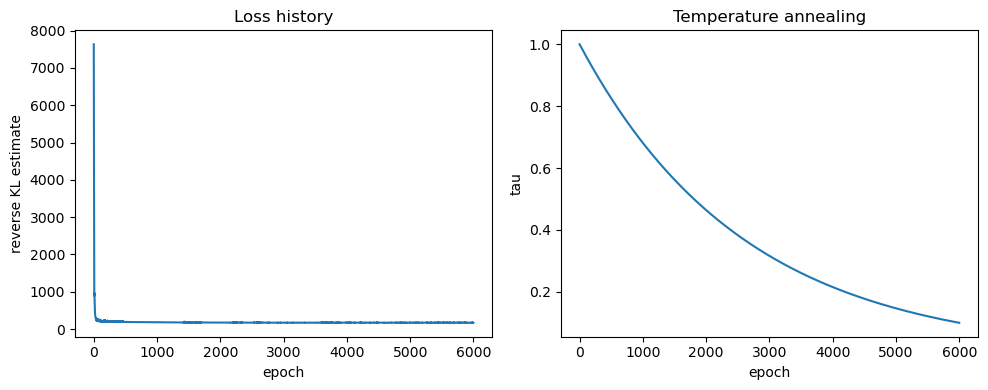

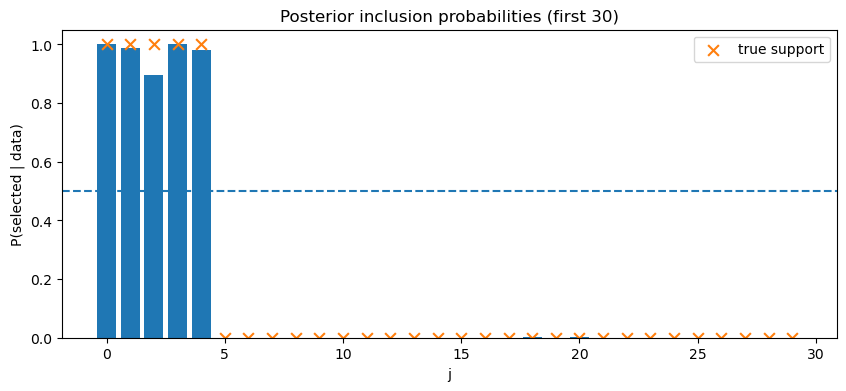

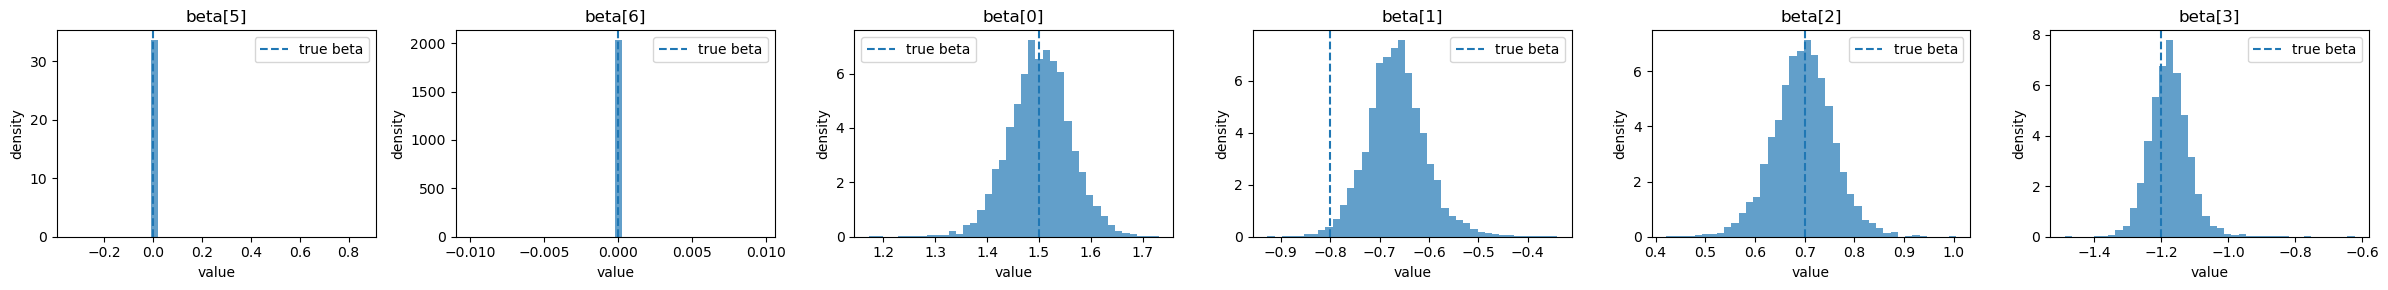

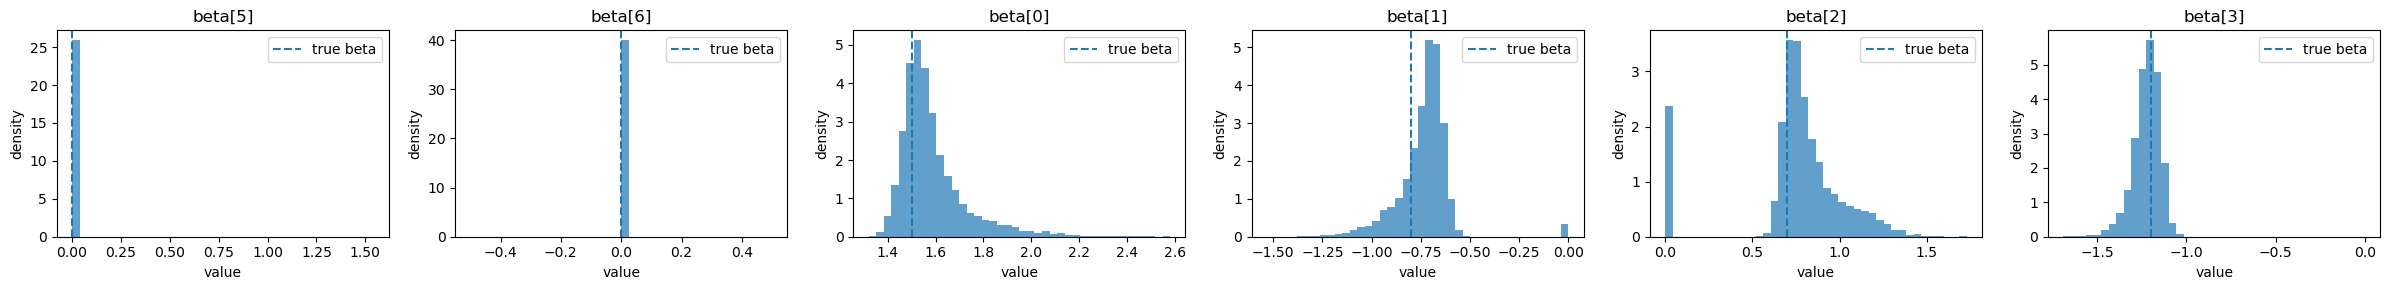

In [7]:
post, results = run_full_single_method_evaluation(
    model=model,
    target_dist=target_dist,
    n_post_samples=5000,
    gate_threshold=0.5,
    inclusion_threshold=0.5,
    beta_true=beta_true,      # 模拟数据时传
    pip_true=None,            # 如果你有真 PIP / MCMC PIP，可以传
    X_train=None,
    y_train=None,
    X_test=None,
    y_test=None,
    exact_gaussian_mean=None, # 一般主实验不需要
    exact_gaussian_cov=None,
    losses=losses,
    tau_hist=tau_hist,
    make_plots=True,
)